<a href="https://colab.research.google.com/github/sharunraj14/ICT_Exam/blob/main/ICT_Exit_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

q1.

In [1]:
import pandas as pd
df= pd.read_csv('/content/Bengaluru_House_Data.csv')

In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [3]:
df = df.dropna(subset=['location','size'])   #to drop rows with missing location or size

df['bath'].fillna(df['bath'].median(), inplace= True)
df['balcony'].fillna(df['balcony'].median(), inplace= True)  #filling bath and balcony with median

/tmp/ipykernel_34716/976347754.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(df['bath'].median(), inplace= True)
/tmp/ipykernel_34716/976347754.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

q2.

In [4]:
#extract bhk

df['bhk']=df['size'].apply(lambda x: int(x.split(' ')[0]))

In [5]:
#converting range to average for total_sqft
def convert_sqft(x):
    try:
        if '-' in str(x):
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df.dropna(subset=['total_sqft'], inplace=True)

q3.

In [6]:
#make price per squarefeet

df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [7]:
#outlier removing

def remove_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()
        reduced = subdf[(subdf['price_per_sqft'] > (m - 3*st)) &
                        (subdf['price_per_sqft'] < (m + 3*st))]
        df_out = pd.concat([df_out, reduced], ignore_index=True)
    return df_out

before = df.shape[0]
df = remove_outliers(df)
after = df.shape[0]

print("Rows removed:", before - after)

Rows removed: 634


q4.

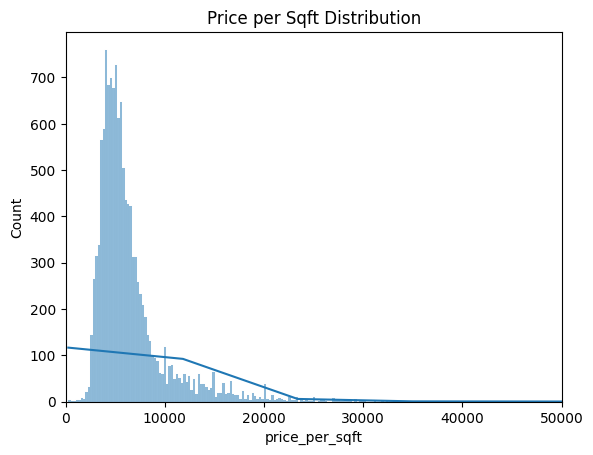

Distribution appears right skewed


In [8]:
#histogram

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price_per_sqft'], kde=True)
plt.xlim(0, 50000)
plt.title("Price per Sqft Distribution")
plt.show()



print("Distribution appears right skewed")

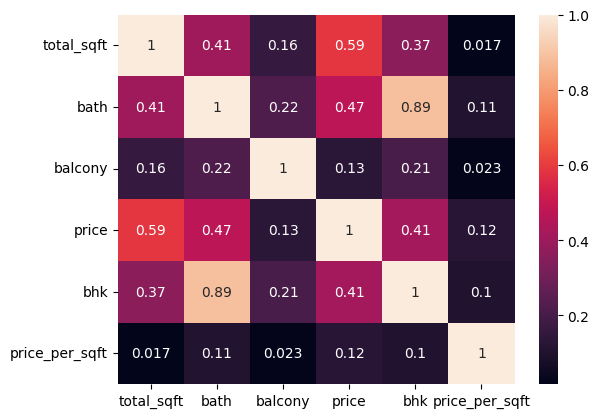

price has a strong correlation with total sqaure feet, 
that means larger sized properties usually have higher prices, 
also bath and bhk also show a moderate correlation with price, 
means no of bathrooms and rooms also contribute to propery value


In [9]:
#heatmap

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.show()


print("price has a strong correlation with total sqaure feet, \nthat means larger sized properties usually have higher prices, \nalso bath and bhk also show a moderate correlation with price, \nmeans no of bathrooms and rooms also contribute to propery value")

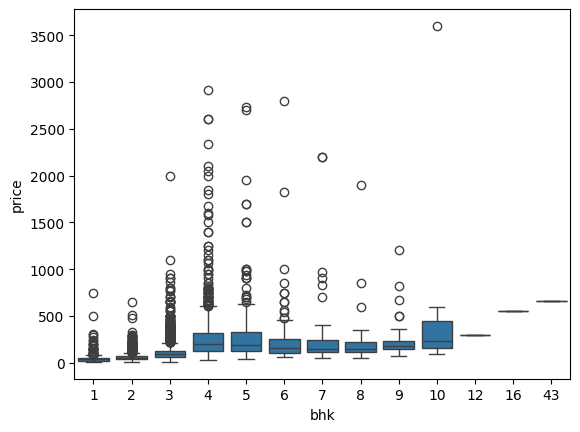

this box plot shows that median property prices generally increase with nuber of bhks
indicating larger houses are more expensive, 
but there are also outliers in all bhk categories indicating variable pricing based on location and amenities


In [10]:
sns.boxplot(x='bhk', y='price', data=df)
plt.show()


print('this box plot shows that median property prices generally increase with nuber of bhks\nindicating larger houses are more expensive, \nbut there are also outliers in all bhk categories indicating variable pricing based on location and amenities')

q5.

In [11]:
#handling location

#top 20 most frequent locations
top_locations = df['location'].value_counts().head(20).index

# Replacing others with 'Other'
df['location'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

In [12]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

print('top 20 frequent locations are retained, remaining are grouped into "Others"')

top 20 frequent locations are retained, remaining are grouped into "Others"


In [13]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft'],
      dtype='object')

In [14]:
#onehot encode area_type

df = pd.get_dummies(df, columns=['area_type'], drop_first=True)

#onhot encoding is used because its a nominal categorical variable with no default order

In [15]:
#Scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['total_sqft', 'bath']] = scaler.fit_transform(df[['total_sqft', 'bath']])


print('min max scaling is applied to total_sqft and bath to bring values to a common range of 0-1\n improving model performance')

min max scaling is applied to total_sqft and bath to bring values to a common range of 0-1
 improving model performance


In [16]:
df.head()
df.shape

(12623, 13)

q6.

In [17]:
X = df.drop(['price', 'availability', 'size', 'society'], axis=1)
y = df['price']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 78.22763734450888
MAE: 36.93774126443964
R2: 0.5822421420801143


In [55]:
# Saving trained model for deployment
import pickle
pickle.dump(lr, open('model.pkl', 'wb'))

In [20]:
print ('using linear regression as baseline model')

using linear regression as baseline model


In [21]:
from sklearn.linear_model import Ridge

# Training Ridge Regression model
ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

#Evaluation
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

#ridge regression prevents overfitting
print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R2:", r2_ridge)

RMSE: 80.59480107450833
MAE: 37.7786982749974
R2: 0.5565769595373802


In [22]:
from sklearn.linear_model import Lasso

#training Lasso Regression model
lasso = Lasso()
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

#evaluation
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

#Lasso regression adds l1 penalty

comparison table

In [23]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        rmse_ridge,
        rmse_lasso
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mae_ridge,
        mae_lasso
    ],
    'R2 Score': [
        r2_score(y_test, y_pred),
        r2_ridge,
        r2_lasso
    ]
})

results



print('linear regression performed the best with lowest RMSE of 78.23 and highest R2 score of 0.58 \n ridge regression performed slightly worse, and lasso showed lowest peformance due to stronger regularization.\n this shows that this dataset does not benefit from heavy regularization.')

linear regression performed the best with lowest RMSE of 78.23 and highest R2 score of 0.58 
 ridge regression performed slightly worse, and lasso showed lowest peformance due to stronger regularization.
 this shows that this dataset does not benefit from heavy regularization.


q7.

In [24]:
#target variable creation(binary)
#1 means high value property >= 100 lakhs
#0 mans low value property

df['high_value'] = df['price'].apply(lambda x: 1 if x >= 100 else 0)

In [25]:
# Fix total_sqft

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df = df.dropna(subset=['total_sqft'])

In [26]:
X = df.drop(['price', 'high_value', 'availability', 'size', 'society'], axis=1)
y = df['high_value']

In [27]:
X = X.fillna(0)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.9045544554455446
Precision: 0.9107142857142857
Recall: 0.751004016064257
F1 Score: 0.8231841526045488


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


the model performs well overall, with high precision buy slighly lower recall

In [30]:
#Naive bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Accuracy: 0.7722772277227723
Precision: 0.8739130434782608
Recall: 0.26907630522088355
F1 Score: 0.41146366427840325


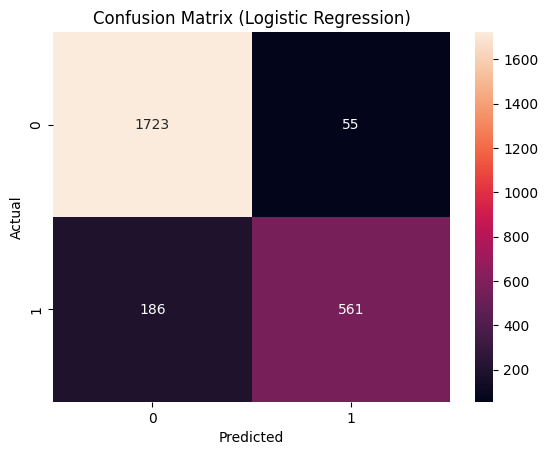

 logistic regression performed better with higher accuracy and f1 score. 
the confusion matrix shows that the model correctly classifies most high/low value properties, but some are still misclassified


In [31]:
#cofusion matrix


import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



print(' logistic regression performed better with higher accuracy and f1 score. \nthe confusion matrix shows that the model correctly classifies most high/low value properties, but some are still misclassified')

q8.

In [32]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [33]:
#GridsearchCV


from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [34]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.9898993718093949


In [35]:
# evaluating best model

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

Accuracy: 0.9912871287128713
Precision: 0.9878869448183042
Recall: 0.9825970548862115
F1 Score: 0.9852348993288591


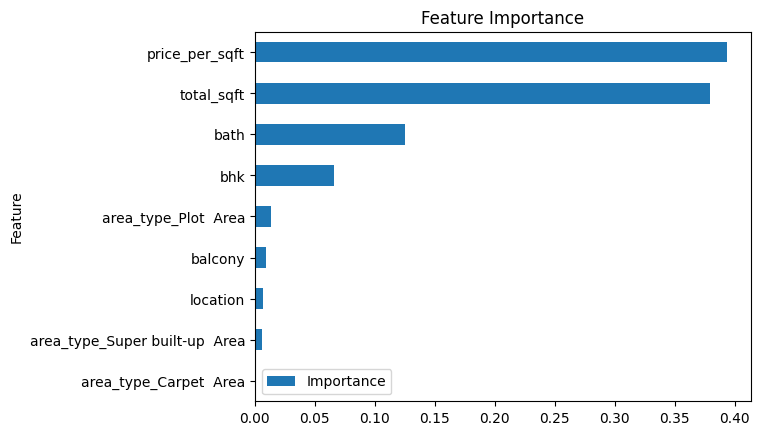

feature importance analysis shows that variables like total_sqft and price_per_sqft have the highest influence on predictions.


In [36]:
#feature importance

importances = best_rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()



print('feature importance analysis shows that variables like total_sqft and price_per_sqft have the highest influence on predictions.')

q9.

K-Means Clustering

In [37]:
X_cluster = df[['total_sqft', 'bath', 'price_per_sqft']]

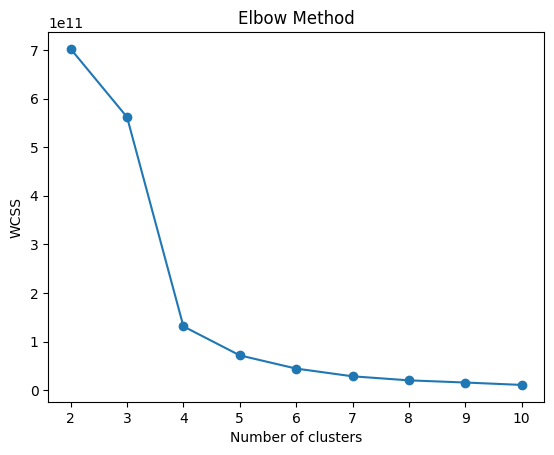

elbow point is at k=4 where the rate of decrease in wcss slows down. so 4 clusters are chosen


In [38]:
#elbow method

from sklearn.cluster import KMeans

wcss = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

print('elbow point is at k=4 where the rate of decrease in wcss slows down. so 4 clusters are chosen')

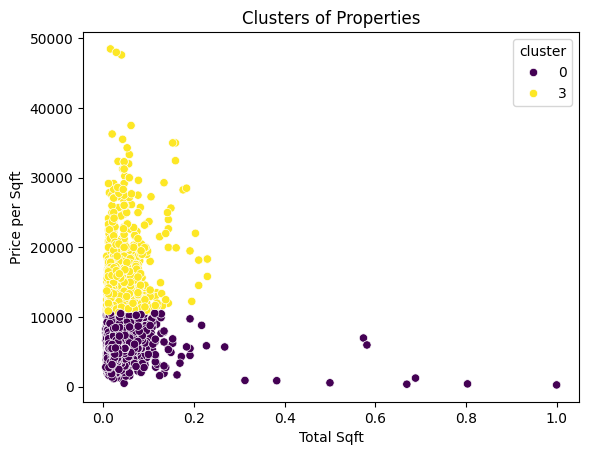

In [45]:
#Scatter plot


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_cluster)

# Assign clusters
df['cluster'] = kmeans.labels_


df_plot = df[df['price_per_sqft'] < 50000]  #Outliers are removed for better visualization of clusters


sns.scatterplot(
    x=df_plot['total_sqft'],
    y=df_plot['price_per_sqft'],
    hue=df_plot['cluster'],
    palette='viridis'
)

plt.title("Clusters of Properties")
plt.xlabel("Total Sqft")
plt.ylabel("Price per Sqft")
plt.show()

q10.

Dimensionality reduction

In [48]:
#preparing the data
X_pca = df.drop(['price', 'high_value', 'cluster', 'availability', 'size', 'society'], axis=1, errors='ignore')

In [49]:
#applying pca

from sklearn.decomposition import PCA

pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca)

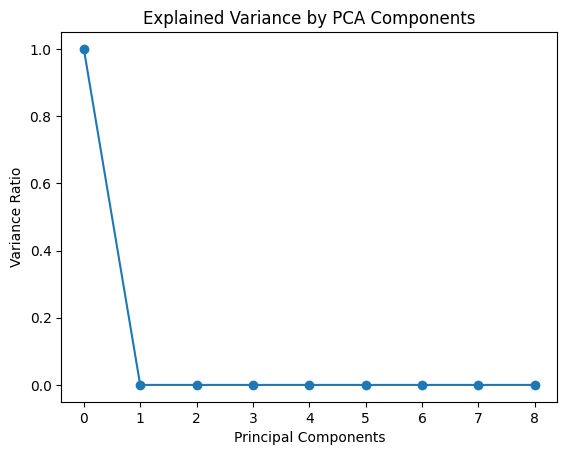

In [50]:
#Variance plot

import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Explained Variance by PCA Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

In [52]:
#reduce to top 5 components
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_pca)

In [53]:
#Training model again

from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca_5, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression

model_pca = LogisticRegression(max_iter=2000)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

In [54]:
#Evaluate

from sklearn.metrics import accuracy_score, f1_score

print("Accuracy (PCA):", accuracy_score(y_test, y_pred_pca))
print("F1 Score (PCA):", f1_score(y_test, y_pred_pca))

Accuracy (PCA): 0.8930693069306931
F1 Score (PCA): 0.8005908419497785


PCA is used to reduce no of features while keeping most of the important information. using the top 5 components make the model simpler and faster, but there is decrease in accuracy, showing trade off between simplicity and performance

q11. streamlit app